# 🏥 Predicción de Readmisión Hospitalaria en Pacientes Diabéticos
## ACIF104 — Aprendizaje Automático | UNAB 2026

---

**Objetivo:** Este cuaderno implementa el pipeline completo del proyecto:
1. Carga y preprocesamiento del dataset
2. Análisis exploratorio de datos (EDA)
3. Entrenamiento de modelos de ML clásico (LR, RF, SVM)
4. Entrenamiento de red neuronal MLP con PyTorch
5. Explicabilidad con Tree SHAP
6. Sistema de predicción interactivo

**Dataset:** `hospital_readmissions.csv` (25.000 registros, 16 predictores + 1 variable objetivo)

---
⚠️ **Instrucción inicial:** Sube el archivo `hospital_readmissions.csv` usando la celda de carga que aparece a continuación.

## ⚙️ PASO 1 — Instalación de dependencias
Ejecuta esta celda primero. Puede tardar 1–2 minutos.

In [1]:
# Instalación de librerías necesarias (solo la primera vez)
import sys

print('Instalando dependencias...')
!pip install -q shap imbalanced-learn torch torchvision --upgrade
print('✓ Dependencias instaladas correctamente.')

Instalando dependencias...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 124.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 106.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━

## 📁 PASO 2 — Carga del dataset

**En Google Colab:** Ejecuta la celda siguiente. Aparecerá un botón "Elegir archivos". Selecciona `hospital_readmissions.csv`.

**En JupyterLab local:** Sube el archivo a la misma carpeta que este cuaderno y ajusta la variable `CSV_PATH`.

In [2]:
import os

# ── Detectar entorno: Google Colab o JupyterLab local ────────
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import files
    print('📂 Selecciona el archivo hospital_readmissions.csv:')
    uploaded = files.upload()
    CSV_PATH = list(uploaded.keys())[0]
    print(f'✓ Archivo cargado: {CSV_PATH}')
else:
    # JupyterLab local: ajusta la ruta si es necesario
    CSV_PATH = 'hospital_readmissions.csv'
    if not os.path.exists(CSV_PATH):
        print(f'✗ Archivo no encontrado: {CSV_PATH}')
        print('  Coloca hospital_readmissions.csv en la misma carpeta que este cuaderno.')
    else:
        print(f'✓ Archivo encontrado: {CSV_PATH}')

📂 Selecciona el archivo hospital_readmissions.csv:


Saving hospital_readmissions.csv to hospital_readmissions.csv
✓ Archivo cargado: hospital_readmissions.csv


## 📦 PASO 3 — Importaciones y configuración global

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, average_precision_score, precision_recall_curve
)
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import shap

# Semillas para reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paleta de colores del proyecto
C = {
    'p': '#1F3864', 's': '#2E75B6', 'a': '#5BA3D9',
    'l': '#A8D1F0', 'r': '#C00000', 'g': '#595959'
}
sns.set_theme(style='whitegrid')

# Nombres legibles de las variables
FEATURES = [
    'time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications',
    'n_outpatient', 'n_inpatient', 'n_emergency', 'age_enc',
    'glucose_test_enc', 'A1Ctest_enc', 'change_enc', 'diabetes_med_enc',
    'medical_specialty_enc', 'diag_1_enc', 'diag_2_enc', 'diag_3_enc'
]
FEAT_LABELS = [
    'Días en hospital', 'Lab. proc.', 'Procedimientos', 'Medicamentos',
    'Visitas ambulat.', 'Ingresos previos', 'Urgencias', 'Edad',
    'Test glucosa', 'Test A1C', 'Cambio medicam.', 'Med. diabetes',
    'Especialidad', 'Diagnóstico 1', 'Diagnóstico 2', 'Diagnóstico 3'
]

print('✓ Librerías importadas correctamente.')
print(f'  PyTorch: {torch.__version__}')
print(f'  SHAP:    {shap.__version__}')
print(f'  GPU disponible: {torch.cuda.is_available()}')

✓ Librerías importadas correctamente.
  PyTorch: 2.11.0+cu130
  SHAP:    0.51.0
  GPU disponible: True


## 🔬 PASO 4 — Carga y preprocesamiento de datos

In [4]:
# ── Carga ─────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
display(df.head(3))

# ── Calidad de datos ──────────────────────────────────────────
print('\n=== Valores nulos por variable ===')
print(df.isnull().sum())

print('\n=== Distribución de la variable objetivo ===')
vc = df['readmitted'].value_counts()
for k, v in vc.items():
    print(f'  {k}: {v:,} ({v/len(df)*100:.1f} %)')

# ── Codificación de variables categóricas ─────────────────────
le = LabelEncoder()
CAT_COLS = ['age', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3',
            'glucose_test', 'A1Ctest', 'change', 'diabetes_med']
for col in CAT_COLS:
    df[col + '_enc'] = le.fit_transform(df[col])

# Variable objetivo binaria
df['target'] = (df['readmitted'] == 'yes').astype(int)

# ── Análisis de valores atípicos (IQR) ───────────────────────
NUM_COLS = ['time_in_hospital', 'n_lab_procedures', 'n_procedures',
            'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency']
print('\n=== Valores atípicos detectados (método IQR) ===')
for col in NUM_COLS:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'  {col:<22}: {n_out:4d} ({n_out/len(df)*100:.2f} %)')

print('\n✓ Preprocesamiento completado.')

Dataset cargado: 25,000 filas × 17 columnas


,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes



=== Valores nulos por variable ===
age                  0
time_in_hospital     0
n_lab_procedures     0
n_procedures         0
n_medications        0
n_outpatient         0
n_inpatient          0
n_emergency          0
medical_specialty    0
diag_1               0
diag_2               0
diag_3               0
glucose_test         0
A1Ctest              0
change               0
diabetes_med         0
readmitted           0
dtype: int64

=== Distribución de la variable objetivo ===
  no: 13,246 (53.0 %)
  yes: 11,754 (47.0 %)

=== Valores atípicos detectados (método IQR) ===
  time_in_hospital      :  580 (2.32 %)
  n_lab_procedures      :   33 (0.13 %)
  n_procedures          : 1227 (4.91 %)
  n_medications         :  844 (3.38 %)
  n_outpatient          : 4141 (16.56 %)
  n_inpatient           : 1628 (6.51 %)
  n_emergency           : 2728 (10.91 %)

✓ Preprocesamiento completado.


## 📊 PASO 5 — Análisis Exploratorio de Datos (EDA)

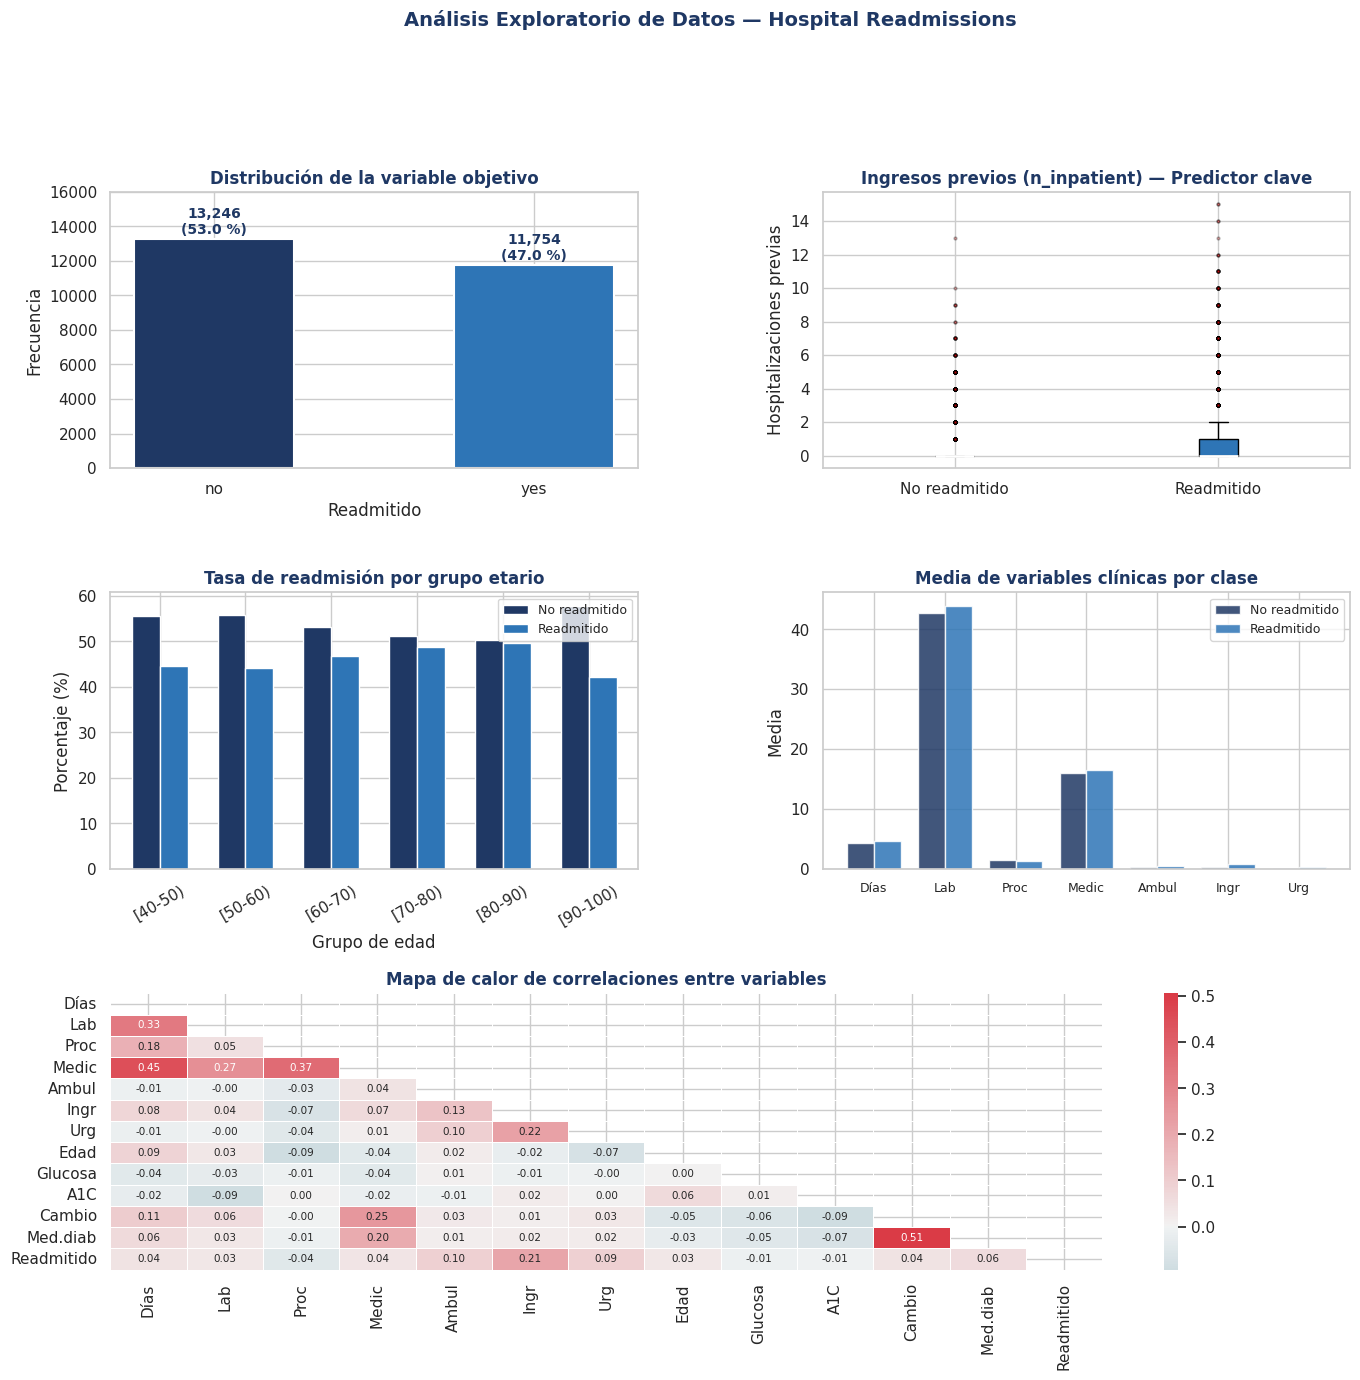

✓ EDA completado. Figura guardada como eda_completo.png


In [5]:
fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Gráfico 1: Distribución de la variable objetivo ───────────
ax1 = fig.add_subplot(gs[0, 0])
vals = df['readmitted'].value_counts().reindex(['no', 'yes'])
bars = ax1.bar(vals.index, vals.values, color=[C['p'], C['s']],
               edgecolor='white', linewidth=1.5, width=0.5)
for bar, v in zip(bars, vals.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
             f'{v:,}\n({v/len(df)*100:.1f} %)',
             ha='center', va='bottom', fontsize=10, fontweight='bold', color=C['p'])
ax1.set_title('Distribución de la variable objetivo', fontsize=12,
               fontweight='bold', color=C['p'])
ax1.set_xlabel('Readmitido'); ax1.set_ylabel('Frecuencia')
ax1.set_ylim(0, 16000)

# ── Gráfico 2: n_inpatient por clase (predictor clave) ────────
ax2 = fig.add_subplot(gs[0, 1])
data_n = df[df['readmitted']=='no']['n_inpatient'].values
data_y = df[df['readmitted']=='yes']['n_inpatient'].values
bp = ax2.boxplot([data_n, data_y], tick_labels=['No readmitido', 'Readmitido'],
                  patch_artist=True,
                  medianprops=dict(color='white', linewidth=2),
                  flierprops=dict(marker='o', markerfacecolor=C['r'],
                                  markersize=2, alpha=0.3))
bp['boxes'][0].set_facecolor(C['p'])
bp['boxes'][1].set_facecolor(C['s'])
ax2.set_title('Ingresos previos (n_inpatient) — Predictor clave',
               fontsize=12, fontweight='bold', color=C['p'])
ax2.set_ylabel('Hospitalizaciones previas')

# ── Gráfico 3: Distribución de edad por clase ─────────────────
ax3 = fig.add_subplot(gs[1, 0])
age_order = ['[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
ct = pd.crosstab(df['age'], df['readmitted']).reindex(age_order)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct[['no', 'yes']].plot(kind='bar', ax=ax3, color=[C['p'], C['s']],
                            edgecolor='white', width=0.65)
ax3.set_title('Tasa de readmisión por grupo etario',
               fontsize=12, fontweight='bold', color=C['p'])
ax3.set_xlabel('Grupo de edad'); ax3.set_ylabel('Porcentaje (%)')
ax3.tick_params(axis='x', rotation=30)
ax3.legend(['No readmitido', 'Readmitido'], fontsize=9)

# ── Gráfico 4: Estadística descriptiva de variables numéricas ─
ax4 = fig.add_subplot(gs[1, 1])
means_n = df[df['readmitted']=='no'][NUM_COLS].mean()
means_y = df[df['readmitted']=='yes'][NUM_COLS].mean()
x = np.arange(len(NUM_COLS))
w = 0.38
ax4.bar(x - w/2, means_n.values, w, label='No readmitido', color=C['p'], alpha=0.85)
ax4.bar(x + w/2, means_y.values, w, label='Readmitido',    color=C['s'], alpha=0.85)
ax4.set_xticks(x)
ax4.set_xticklabels(['Días', 'Lab', 'Proc', 'Medic', 'Ambul', 'Ingr', 'Urg'],
                     fontsize=9)
ax4.set_title('Media de variables clínicas por clase',
               fontsize=12, fontweight='bold', color=C['p'])
ax4.set_ylabel('Media'); ax4.legend(fontsize=9)

# ── Gráfico 5: Mapa de calor de correlaciones ─────────────────
ax5 = fig.add_subplot(gs[2, :])
num_enc = NUM_COLS + ['age_enc', 'glucose_test_enc', 'A1Ctest_enc',
                       'change_enc', 'diabetes_med_enc', 'target']
corr = df[num_enc].corr()
labels_short = ['Días','Lab','Proc','Medic','Ambul','Ingr','Urg',
                 'Edad','Glucosa','A1C','Cambio','Med.diab','Readmitido']
sns.heatmap(corr, ax=ax5, cmap=sns.diverging_palette(220, 10, as_cmap=True),
            center=0, annot=True, fmt='.2f', linewidths=0.4,
            annot_kws={'size': 7.5},
            xticklabels=labels_short, yticklabels=labels_short,
            mask=np.triu(np.ones_like(corr, dtype=bool)))
ax5.set_title('Mapa de calor de correlaciones entre variables',
               fontsize=12, fontweight='bold', color=C['p'])

plt.suptitle('Análisis Exploratorio de Datos — Hospital Readmissions',
             fontsize=14, fontweight='bold', color=C['p'], y=1.01)
plt.savefig('eda_completo.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ EDA completado. Figura guardada como eda_completo.png')

## ✂️ PASO 6 — Partición estratificada y balanceo de clases

In [6]:
# ── Vectores de entrada y salida ──────────────────────────────
X = df[FEATURES].values.astype(np.float32)
y = df['target'].values

# ── Partición estratificada 70 / 15 / 15 ──────────────────────
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.1765, stratify=y_tmp, random_state=SEED)

print('=== Partición del dataset ===')
for name, xs, ys in [('Entrenamiento', X_train, y_train),
                      ('Validación',    X_val,   y_val),
                      ('Prueba',        X_test,  y_test)]:
    n0 = (ys==0).sum(); n1 = (ys==1).sum()
    print(f'  {name:<14}: {len(xs):6,} registros | '
          f'No readmit.: {n0:,} ({n0/len(ys)*100:.1f} %) | '
          f'Readmitido: {n1:,} ({n1/len(ys)*100:.1f} %)')

# ── Normalización (StandardScaler ajustado solo en train) ─────
sc      = StandardScaler()
Xtr_s   = sc.fit_transform(X_train).astype(np.float32)
Xv_s    = sc.transform(X_val).astype(np.float32)
Xte_s   = sc.transform(X_test).astype(np.float32)

# ── Tres estrategias de balanceo ──────────────────────────────
sm  = SMOTE(random_state=SEED)
ros = RandomOverSampler(random_state=SEED)
rus = RandomUnderSampler(random_state=SEED)

Xsm,  ysm  = sm.fit_resample(Xtr_s, y_train)
Xros, yros = ros.fit_resample(Xtr_s, y_train)
Xrus, yrus = rus.fit_resample(Xtr_s, y_train)

Xsm  = Xsm.astype(np.float32);  ysm  = ysm.astype(np.float32)
Xros = Xros.astype(np.float32); yros = yros.astype(np.float32)
Xrus = Xrus.astype(np.float32); yrus = yrus.astype(np.float32)

print('\n=== Conjuntos de entrenamiento tras balanceo ===')
for name, xs, ys in [('Sin balanceo', Xtr_s, y_train),
                      ('SMOTE',        Xsm,   ysm),
                      ('ROS',          Xros,  yros),
                      ('RUS',          Xrus,  yrus)]:
    u, c = np.unique(ys, return_counts=True)
    print(f'  {name:<15}: {len(xs):6,} muestras | dist: {dict(zip(u.astype(int), c))}')

print('\n✓ Partición y balanceo completados.')

=== Partición del dataset ===
  Entrenamiento : 17,499 registros | No readmit.: 9,272 (53.0 %) | Readmitido: 8,227 (47.0 %)
  Validación    :  3,751 registros | No readmit.: 1,987 (53.0 %) | Readmitido: 1,764 (47.0 %)
  Prueba        :  3,750 registros | No readmit.: 1,987 (53.0 %) | Readmitido: 1,763 (47.0 %)

=== Conjuntos de entrenamiento tras balanceo ===
  Sin balanceo   : 17,499 muestras | dist: {np.int64(0): np.int64(9272), np.int64(1): np.int64(8227)}
  SMOTE          : 18,544 muestras | dist: {np.int64(0): np.int64(9272), np.int64(1): np.int64(9272)}
  ROS            : 18,544 muestras | dist: {np.int64(0): np.int64(9272), np.int64(1): np.int64(9272)}
  RUS            : 16,454 muestras | dist: {np.int64(0): np.int64(8227), np.int64(1): np.int64(8227)}

✓ Partición y balanceo completados.


## 🤖 PASO 7 — Modelos de Machine Learning Clásico
Se entrenan Regresión Logística, Random Forest y SVM con SMOTE.

In [7]:
print('Entrenando modelos de ML clásico con SMOTE...')

# ── Entrenamiento ─────────────────────────────────────────────
lr  = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
rf  = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
svm = SVC(kernel='rbf', probability=True, random_state=SEED, max_iter=2000)

lr.fit(Xsm, ysm);       print('  ✓ Regresión Logística entrenada.')
rf.fit(Xsm, ysm);       print('  ✓ Random Forest entrenado.')
svm.fit(Xsm[:5000], ysm[:5000]);  print('  ✓ SVM entrenado (submuestra 5 000 por velocidad).')

# ── Evaluación en conjunto de prueba ──────────────────────────
print('\n=== Métricas en el conjunto de prueba ===')
resultados_ml = {}
for nombre, modelo in [('Reg. Logística', lr), ('Random Forest', rf), ('SVM (RBF)', svm)]:
    probs = modelo.predict_proba(Xte_s)[:, 1]
    preds = (probs > 0.5).astype(int)
    resultados_ml[nombre] = {
        'AUC-ROC':   round(roc_auc_score(y_test, probs), 4),
        'F1-macro':  round(f1_score(y_test, preds, average='macro'), 4),
        'Precisión': round(precision_score(y_test, preds), 4),
        'Recall':    round(recall_score(y_test, preds), 4),
        'Accuracy':  round((preds == y_test).mean(), 4),
    }
    print(f'\n  {nombre}:')
    for k, v in resultados_ml[nombre].items():
        print(f'    {k:<12}: {v}')

print('\n✓ Modelos de ML evaluados.')

Entrenando modelos de ML clásico con SMOTE...
  ✓ Regresión Logística entrenada.
  ✓ Random Forest entrenado.
  ✓ SVM entrenado (submuestra 5 000 por velocidad).

=== Métricas en el conjunto de prueba ===

  Reg. Logística:
    AUC-ROC     : 0.6428
    F1-macro    : 0.6003
    Precisión   : 0.6057
    Recall      : 0.4861
    Accuracy    : 0.6096

  Random Forest:
    AUC-ROC     : 0.6376
    F1-macro    : 0.5968
    Precisión   : 0.5806
    Recall      : 0.5394
    Accuracy    : 0.6003

  SVM (RBF):
    AUC-ROC     : 0.6278
    F1-macro    : 0.5865
    Precisión   : 0.5799
    Recall      : 0.4918
    Accuracy    : 0.5936

✓ Modelos de ML evaluados.


## 🧠 PASO 8 — Red Neuronal MLP con PyTorch
Arquitectura: [128 → 64 → 32] con BatchNorm, ReLU y Dropout(0.3)

In [8]:
# ── Definición del MLP ────────────────────────────────────────
class MLP(nn.Module):
    """Perceptrón Multicapa para clasificación binaria."""
    def __init__(self, in_dim=16, hidden=[128, 64, 32], dropout=0.3):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            prev = h
        layers.append(nn.Linear(prev, 1))   # Salida escalar (logit)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)

# ── Preparación de datos para PyTorch ─────────────────────────
ds_train = TensorDataset(torch.tensor(Xsm), torch.tensor(ysm))
loader   = DataLoader(ds_train, batch_size=256, shuffle=True)
Xv_t     = torch.tensor(Xv_s)
Xte_t    = torch.tensor(Xte_s)

# ── Entrenamiento ─────────────────────────────────────────────
EPOCHS = 60
mlp    = MLP()
crit   = nn.BCEWithLogitsLoss()
opt    = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
sch    = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)

tr_losses, vl_losses = [], []
best_auc, best_state = 0, None

print(f'Entrenando MLP durante {EPOCHS} épocas...')
for ep in range(EPOCHS):
    mlp.train()
    ep_loss = []
    for bx, by in loader:
        opt.zero_grad()
        loss = crit(mlp(bx), by)
        loss.backward(); opt.step()
        ep_loss.append(loss.item())

    mlp.eval()
    with torch.no_grad():
        vo   = mlp(Xv_t)
        vl   = crit(vo, torch.tensor(y_val, dtype=torch.float32)).item()
        vp   = torch.sigmoid(vo).numpy()
        vauc = roc_auc_score(y_val, vp)

    sch.step(vl)
    tr_losses.append(np.mean(ep_loss))
    vl_losses.append(vl)

    if vauc > best_auc:
        best_auc   = vauc
        best_state = {k: v.clone() for k, v in mlp.state_dict().items()}

    if (ep + 1) % 20 == 0:
        print(f'  Época {ep+1:3d}: '
              f'train_loss={tr_losses[-1]:.4f}  '
              f'val_loss={vl:.4f}  '
              f'val_AUC={vauc:.4f}')

mlp.load_state_dict(best_state)
print(f'\n✓ Mejor AUC-ROC en validación: {best_auc:.4f}')

# ── Evaluación en prueba ───────────────────────────────────────
mlp.eval()
with torch.no_grad():
    mlp_probs = torch.sigmoid(mlp(Xte_t)).numpy()
mlp_preds = (mlp_probs > 0.5).astype(int)

print(f'\n=== MLP — Conjunto de prueba ===')
print(f'  AUC-ROC:  {roc_auc_score(y_test, mlp_probs):.4f}')
print(f'  F1-macro: {f1_score(y_test, mlp_preds, average="macro"):.4f}')
print(classification_report(y_test, mlp_preds,
      target_names=['No readmit.', 'Readmitido']))

Entrenando MLP durante 60 épocas...
  Época  20: train_loss=0.6493  val_loss=0.6566  val_AUC=0.6539
  Época  40: train_loss=0.6419  val_loss=0.6563  val_AUC=0.6534
  Época  60: train_loss=0.6402  val_loss=0.6565  val_AUC=0.6530

✓ Mejor AUC-ROC en validación: 0.6542

=== MLP — Conjunto de prueba ===
  AUC-ROC:  0.6445
  F1-macro: 0.6070
              precision    recall  f1-score   support

 No readmit.       0.63      0.66      0.64      1987
  Readmitido       0.59      0.55      0.57      1763

    accuracy                           0.61      3750
   macro avg       0.61      0.61      0.61      3750
weighted avg       0.61      0.61      0.61      3750



## 📈 PASO 9 — Comparación de modelos y visualizaciones

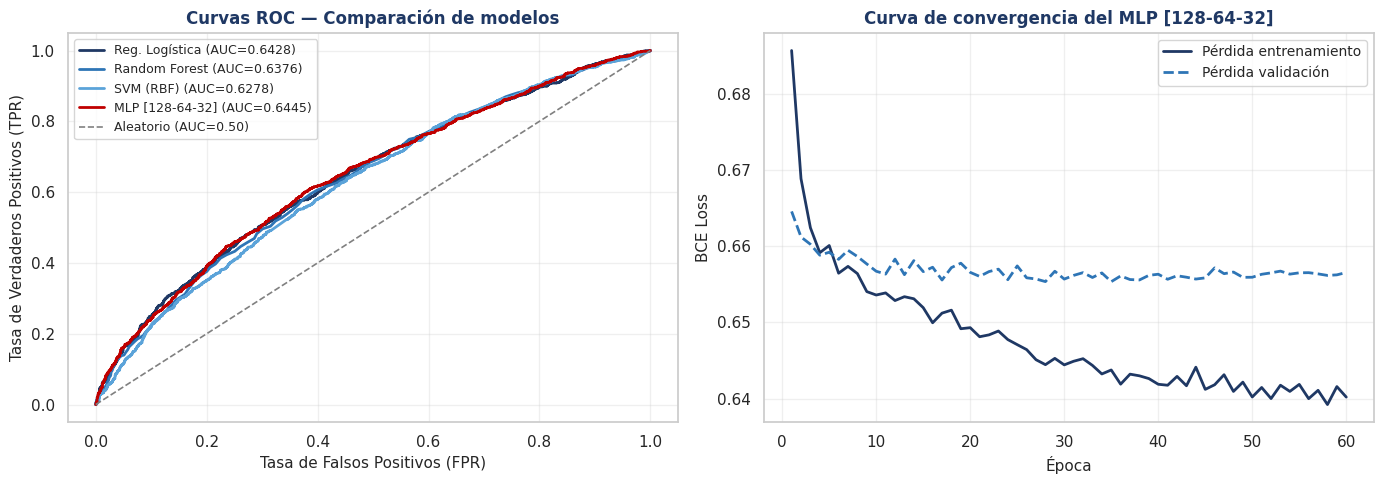


=== Tabla resumen de métricas en el conjunto de prueba ===


,AUC-ROC,F1-macro,Precisión,Recall,Accuracy
Reg. Logística,0.642800,0.600300,0.605700,0.486100,0.609600
Random Forest,0.637600,0.596800,0.580600,0.539400,0.600300
SVM (RBF),0.627800,0.586500,0.579900,0.491800,0.593600
MLP [128-64-32],0.644500,0.607000,0.591200,0.553600,0.610100


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Curvas ROC ────────────────────────────────────────────────
ax = axes[0]
lr_probs  = lr.predict_proba(Xte_s)[:, 1]
rf_probs  = rf.predict_proba(Xte_s)[:, 1]
svm_probs = svm.predict_proba(Xte_s)[:, 1]

for nombre, probs, col in [
    ('Reg. Logística', lr_probs,  C['p']),
    ('Random Forest',  rf_probs,  C['s']),
    ('SVM (RBF)',      svm_probs, C['a']),
    ('MLP [128-64-32]',mlp_probs, C['r'])
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=col, lw=2, label=f'{nombre} (AUC={auc:.4f})')

ax.plot([0,1],[0,1], '--', color='gray', lw=1.2, label='Aleatorio (AUC=0.50)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title('Curvas ROC — Comparación de modelos', fontsize=12,
              fontweight='bold', color=C['p'])
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Convergencia del MLP ───────────────────────────────────────
ax2 = axes[1]
ax2.plot(range(1, EPOCHS+1), tr_losses, color=C['p'], lw=2,
         label='Pérdida entrenamiento')
ax2.plot(range(1, EPOCHS+1), vl_losses, color=C['s'], lw=2, ls='--',
         label='Pérdida validación')
ax2.set_xlabel('Época', fontsize=11); ax2.set_ylabel('BCE Loss', fontsize=11)
ax2.set_title('Curva de convergencia del MLP [128-64-32]',
               fontsize=12, fontweight='bold', color=C['p'])
ax2.legend(fontsize=10); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tabla resumen de métricas ─────────────────────────────────
todos = dict(resultados_ml)
todos['MLP [128-64-32]'] = {
    'AUC-ROC':   round(roc_auc_score(y_test, mlp_probs), 4),
    'F1-macro':  round(f1_score(y_test, mlp_preds, average='macro'), 4),
    'Precisión': round(precision_score(y_test, mlp_preds), 4),
    'Recall':    round(recall_score(y_test, mlp_preds), 4),
    'Accuracy':  round((mlp_preds == y_test).mean(), 4),
}
df_res = pd.DataFrame(todos).T
print('\n=== Tabla resumen de métricas en el conjunto de prueba ===')
display(df_res.style.highlight_max(axis=0, color='#A8D1F0'))

## 🔍 PASO 10 — Explicabilidad con Tree SHAP

Calculando valores SHAP (puede tardar 2–5 minutos)...
✓ Valores SHAP calculados. Forma: (300, 16)


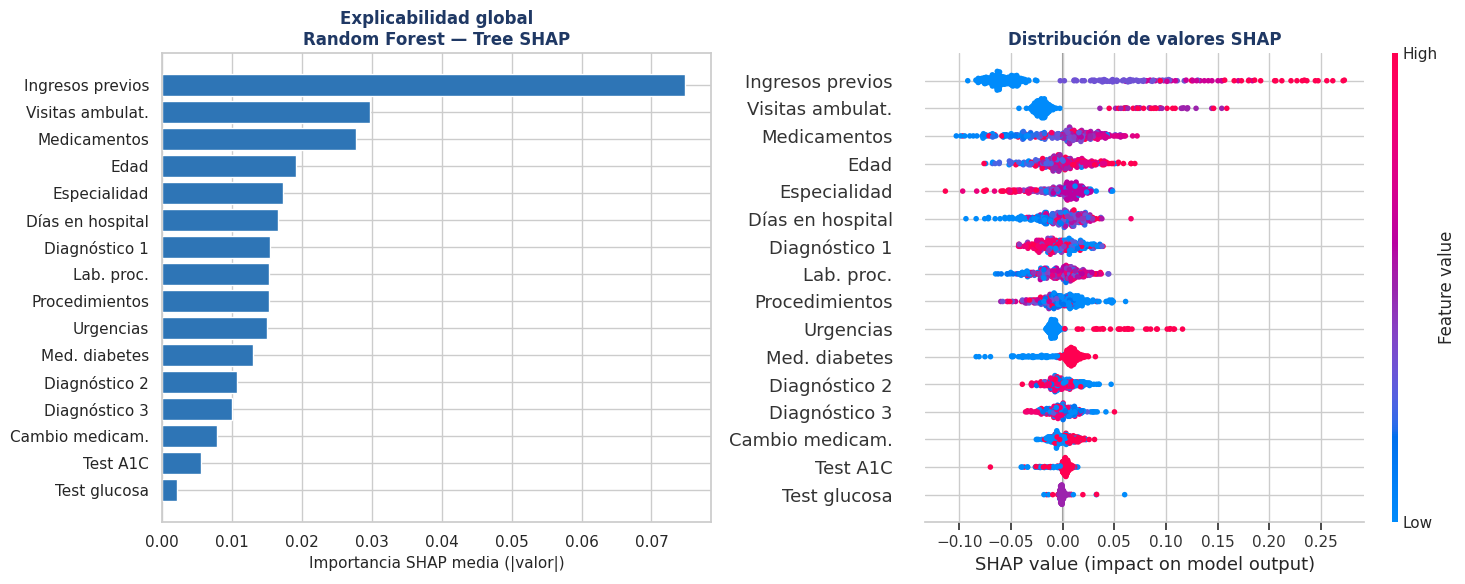


=== Explicación local — Paciente de alto riesgo (índice 5) ===
  Probabilidad de readmisión: 86.0 %
  Contribución de cada variable (top 8):
    Ingresos previos      : +0.1248  (▲ aumenta riesgo)
    Visitas ambulat.      : +0.0783  (▲ aumenta riesgo)
    Medicamentos          : +0.0311  (▲ aumenta riesgo)
    Edad                  : +0.0221  (▲ aumenta riesgo)
    Lab. proc.            : +0.0206  (▲ aumenta riesgo)
    Diagnóstico 2         : +0.0189  (▲ aumenta riesgo)
    Días en hospital      : +0.0151  (▲ aumenta riesgo)
    Procedimientos        : +0.0144  (▲ aumenta riesgo)


In [10]:
print('Calculando valores SHAP (puede tardar 2–5 minutos)...')
explainer = shap.TreeExplainer(rf)
X_shap    = Xte_s[:300]          # Submuestra para eficiencia
sv_raw    = explainer.shap_values(X_shap)

# Extraer valores para la clase positiva
if isinstance(sv_raw, list):
    sv = sv_raw[1]
elif sv_raw.ndim == 3:
    sv = sv_raw[:, :, 1]
else:
    sv = sv_raw

print(f'✓ Valores SHAP calculados. Forma: {sv.shape}')

# ── Gráfico 1: Importancia global (barras) ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
mean_abs  = np.abs(sv).mean(axis=0)
order     = np.argsort(mean_abs)

ax = axes[0]
ax.barh([FEAT_LABELS[i] for i in order], mean_abs[order], color=C['s'])
ax.set_xlabel('Importancia SHAP media (|valor|)', fontsize=11)
ax.set_title('Explicabilidad global\nRandom Forest — Tree SHAP',
              fontsize=12, fontweight='bold', color=C['p'])

# ── Gráfico 2: Beeswarm ───────────────────────────────────────
plt.sca(axes[1])
shap.summary_plot(sv, X_shap, feature_names=FEAT_LABELS,
                  show=False, plot_size=None)
plt.title('Distribución de valores SHAP', fontsize=12,
           fontweight='bold', color=C['p'])

plt.tight_layout()
plt.savefig('shap_explicabilidad.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Explicación local: un paciente de alto riesgo ─────────────
print('\n=== Explicación local — Paciente de alto riesgo (índice 5) ===')
idx      = 5
sv_local = sv[idx]
prob_loc = rf.predict_proba(X_shap[idx:idx+1])[0][1]
print(f'  Probabilidad de readmisión: {prob_loc*100:.1f} %')
print('  Contribución de cada variable (top 8):')
pares = sorted(zip(FEAT_LABELS, sv_local), key=lambda x: abs(x[1]), reverse=True)[:8]
for lbl, val in pares:
    signo = '▲ aumenta riesgo' if val > 0 else '▼ reduce riesgo'
    print(f'    {lbl:<22}: {val:+.4f}  ({signo})')

## 🖥️ PASO 11 — Sistema de Predicción Interactivo

Ingresa los datos de un paciente y obtén la predicción junto con la explicación SHAP.

In [11]:
def predecir_paciente(
    time_in_hospital=5,
    n_lab_procedures=45,
    n_procedures=1,
    n_medications=18,
    n_outpatient=0,
    n_inpatient=2,        # ← Variable más importante
    n_emergency=0,
    age_enc=3,            # 0=[40-50) … 5=[90-100)
    glucose_test_enc=0,   # 0=sin test, 1=normal, 2=alto
    A1Ctest_enc=2,        # 0=sin test, 1=normal, 2=alto
    change_enc=1,         # 0=no, 1=sí
    diabetes_med_enc=1,   # 0=no, 1=sí
    medical_specialty_enc=3,
    diag_1_enc=2,
    diag_2_enc=1,
    diag_3_enc=4,
    modelo=rf
):
    """
    Predice la probabilidad de readmisión hospitalaria para un paciente
    diabético y genera la explicación mediante valores SHAP.

    Parámetros
    ----------
    Todos los atributos clínicos del paciente (ver nombres de variables).
    modelo : estimador entrenado (por defecto, Random Forest).

    Retorna
    -------
    dict con 'readmitido', 'probabilidad', 'riesgo' y 'shap_values'.
    """
    valores = [
        time_in_hospital, n_lab_procedures, n_procedures, n_medications,
        n_outpatient, n_inpatient, n_emergency, age_enc,
        glucose_test_enc, A1Ctest_enc, change_enc, diabetes_med_enc,
        medical_specialty_enc, diag_1_enc, diag_2_enc, diag_3_enc
    ]
    X_raw = np.array(valores, dtype=np.float32).reshape(1, -1)
    X_sc  = sc.transform(X_raw)
    prob  = float(modelo.predict_proba(X_sc)[0][1])
    pred  = int(prob > 0.5)

    # Etiqueta de riesgo
    if prob >= 0.60:
        riesgo = '🔴 ALTO   — Intervención preventiva recomendada'
    elif prob >= 0.40:
        riesgo = '🟠 MODERADO — Seguimiento reforzado recomendado'
    else:
        riesgo = '🟢 BAJO   — Seguimiento estándar'

    # Valores SHAP locales
    sv_loc_raw = explainer.shap_values(X_sc)
    if isinstance(sv_loc_raw, list):
        sv_loc = sv_loc_raw[1][0]
    elif sv_loc_raw.ndim == 3:
        sv_loc = sv_loc_raw[0, :, 1]
    else:
        sv_loc = sv_loc_raw[0]

    # Mostrar resultado
    separador = '─' * 55
    print(separador)
    print('  RESULTADO DE LA PREDICCIÓN')
    print(separador)
    print(f'  ¿Readmisión predicha?  {"SÍ" if pred else "NO"}')
    print(f'  Probabilidad:          {prob*100:.1f} %')
    print(f'  Nivel de riesgo:       {riesgo}')
    print(separador)
    print('  TOP 8 FACTORES MÁS INFLUYENTES (SHAP)')
    print(separador)
    pares = sorted(zip(FEAT_LABELS, sv_loc),
                   key=lambda x: abs(x[1]), reverse=True)[:8]
    for lbl, val in pares:
        barra = '█' * int(abs(val) * 300)
        signo = '+' if val >= 0 else '-'
        dire  = '▲ riesgo' if val >= 0 else '▼ riesgo'
        print(f'  {lbl:<22} {signo}{abs(val):.4f}  {barra[:20]:<20} {dire}')
    print(separador)

    return {
        'readmitido':  pred,
        'probabilidad': round(prob, 4),
        'riesgo':      riesgo,
        'shap_values': dict(zip(FEAT_LABELS, sv_loc.round(4).tolist()))
    }


# ── Ejemplo 1: Paciente de alto riesgo ────────────────────────
print('\n📋 EJEMPLO 1 — Paciente con hospitalizaciones previas frecuentes')
r1 = predecir_paciente(
    time_in_hospital=8,
    n_inpatient=5,          # Múltiples hospitalizaciones previas
    n_lab_procedures=70,
    n_medications=25,
    A1Ctest_enc=2,          # HbA1c elevada
    change_enc=1,
    n_emergency=2
)


📋 EJEMPLO 1 — Paciente con hospitalizaciones previas frecuentes
───────────────────────────────────────────────────────
  RESULTADO DE LA PREDICCIÓN
───────────────────────────────────────────────────────
  ¿Readmisión predicha?  SÍ
  Probabilidad:          83.5 %
  Nivel de riesgo:       🔴 ALTO   — Intervención preventiva recomendada
───────────────────────────────────────────────────────
  TOP 8 FACTORES MÁS INFLUYENTES (SHAP)
───────────────────────────────────────────────────────
  Ingresos previos       +0.2269  ████████████████████ ▲ riesgo
  Urgencias              +0.0568  █████████████████    ▲ riesgo
  Medicamentos           +0.0314  █████████            ▲ riesgo
  Diagnóstico 2          +0.0186  █████                ▲ riesgo
  Test A1C               -0.0167  █████                ▼ riesgo
  Edad                   -0.0114  ███                  ▼ riesgo
  Días en hospital       +0.0113  ███                  ▲ riesgo
  Med. diabetes          +0.0093  ██                   ▲ riesg

In [16]:
# ── Ejemplo 2: Paciente de bajo riesgo ────────────────────────
print('\n📋 EJEMPLO 2 — Paciente con primer ingreso y buen control metabólico')
r2 = predecir_paciente(
    time_in_hospital=3,
    n_inpatient=0,          # Sin hospitalizaciones previas
    n_lab_procedures=30,
    n_medications=10,
    A1Ctest_enc=1,          # HbA1c normal
    change_enc=0,
    n_emergency=0
)

# ── Tu turno: personaliza los valores del paciente ────────────
print('\n📋 EJEMPLO 3 — Ingresa tus propios datos')
print('(Modifica los parámetros de la función y vuelve a ejecutar)')
r3 = predecir_paciente(
    time_in_hospital=1,
    n_lab_procedures=2,
    n_procedures=1,
    n_medications=1,
    n_outpatient=0,
    n_inpatient=1,
    n_emergency=0,
    age_enc=3,
    A1Ctest_enc=0,
    change_enc=1,
    diabetes_med_enc=1
)


📋 EJEMPLO 2 — Paciente con primer ingreso y buen control metabólico
───────────────────────────────────────────────────────
  RESULTADO DE LA PREDICCIÓN
───────────────────────────────────────────────────────
  ¿Readmisión predicha?  NO
  Probabilidad:          42.0 %
  Nivel de riesgo:       🟠 MODERADO — Seguimiento reforzado recomendado
───────────────────────────────────────────────────────
  TOP 8 FACTORES MÁS INFLUYENTES (SHAP)
───────────────────────────────────────────────────────
  Ingresos previos       -0.0620  ██████████████████   ▼ riesgo
  Medicamentos           -0.0408  ████████████         ▼ riesgo
  Test glucosa           +0.0323  █████████            ▲ riesgo
  Diagnóstico 1          +0.0226  ██████               ▲ riesgo
  Especialidad           -0.0196  █████                ▼ riesgo
  Visitas ambulat.       -0.0194  █████                ▼ riesgo
  Edad                   +0.0139  ████                 ▲ riesgo
  Diagnóstico 3          -0.0133  ███                  ▼ r

## 💾 PASO 12 — Guardar modelos entrenados
Los archivos generados pueden descargarse desde el panel lateral de Colab.

In [13]:
import joblib, os

os.makedirs('modelos', exist_ok=True)

# Guardar Random Forest y StandardScaler
joblib.dump(rf, 'modelos/rf_model.pkl')
joblib.dump(sc, 'modelos/scaler.pkl')
print('✓ Modelos guardados en la carpeta modelos/')

# Guardar figuras (ya guardadas en pasos anteriores)
print('✓ Figuras disponibles: eda_completo.png, comparacion_modelos.png, shap_explicabilidad.png')

# En Google Colab: descargar archivos
if IN_COLAB:
    from google.colab import files
    print('\n📥 Descargando modelos...')
    files.download('modelos/rf_model.pkl')
    files.download('modelos/scaler.pkl')
    print('\n📥 Descargando figuras...')
    files.download('eda_completo.png')
    files.download('comparacion_modelos.png')
    files.download('shap_explicabilidad.png')
    print('✓ Descarga completada.')
else:
    print('(En JupyterLab local: los archivos ya están en la carpeta del cuaderno.)')

print('\n✅ Pipeline completo ejecutado exitosamente.')

✓ Modelos guardados en la carpeta modelos/
✓ Figuras disponibles: eda_completo.png, comparacion_modelos.png, shap_explicabilidad.png

📥 Descargando modelos...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Descarga completada.

✅ Pipeline completo ejecutado exitosamente.


---
## 📚 Referencias

- Kaul, K. et al. (2022). *Predicting 30-day readmission in diabetic patients using ML.* Journal of Diabetes Science and Technology.
- Lundberg, S. M. y Lee, S. (2017). *A unified approach to interpreting model predictions.* NeurIPS.
- Strack, B. et al. (2014). *Impact of HbA1c on hospital readmission rates.* BioMed Research International.
- Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction.* MIT Press.
- Zhang, A. et al. (2023). *Dive into Deep Learning.* Cambridge University Press.

---
**ACIF104 — Aprendizaje Automático | UNAB 2026**